# C5-ex1: Practice on k-Nearest Neighbors (k-NN)

**Nguyễn Phúc Minh Châu - 22302421**

This exercise helps you understand how the **k-Nearest Neighbors** algorithm works.

Answer each question in the code cell below it.

## Question 1
**Compute the Euclidean distance between two 2D points A(2, 3) and B(7, 9).**

_Hint: You can use `numpy.linalg.norm()` or the mathematical formula._

In [1]:
# Tính khoảng cách Euclid giữa hai điểm A và B
import numpy as np

# TODO: Khai báo 2 vector A và B
A = np.array([1, 5])
B = np.array([3, 6])

# TODO: Tính khoảng cách Euclid
distance = np.linalg.norm(A - B)
print("Euclidean distance between A and B:", distance)

Euclidean distance between A and B: 2.23606797749979


## Question 2
**Load the Iris dataset and display the first 5 rows of data.**

_Hint: Use `load_iris()` from `sklearn.datasets` and convert to a DataFrame for easier viewing._

In [2]:
# Hiển thị 5 dòng đầu tiên của dữ liệu Iris
from sklearn.datasets import load_iris
import pandas as pd

# TODO: Tải dữ liệu
data = load_iris()

# TODO: Tạo DataFrame từ data
df = pd.DataFrame(data.data, columns=data.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Question 3
**Split the Iris dataset into training (70%) and testing (30%) sets.**

_Hint: Use `train_test_split()` from `sklearn.model_selection`._

In [3]:
# Chia dữ liệu thành tập huấn luyện và kiểm tra
from sklearn.model_selection import train_test_split

# TODO: X và y lấy từ dữ liệu Iris
X = data.data
y = data.target

# TODO: Chia dữ liệu (test_size=0.3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train.shape, X_test.shape)

(105, 4) (45, 4)


## Question 4
**Train a k-Nearest Neighbors classifier with k = 5 and test its accuracy.**

In [8]:
# Huấn luyện mô hình kNN và đánh giá độ chính xác
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# TODO: Khởi tạo mô hình KNN với k=5
knn = KNeighborsClassifier(n_neighbors=5)

# TODO: Huấn luyện mô hình
knn.fit(X_train, y_train)

# TODO: Dự đoán trên tập kiểm tra
y_pred = knn.predict(X_test)

# TODO: Tính độ chính xác
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



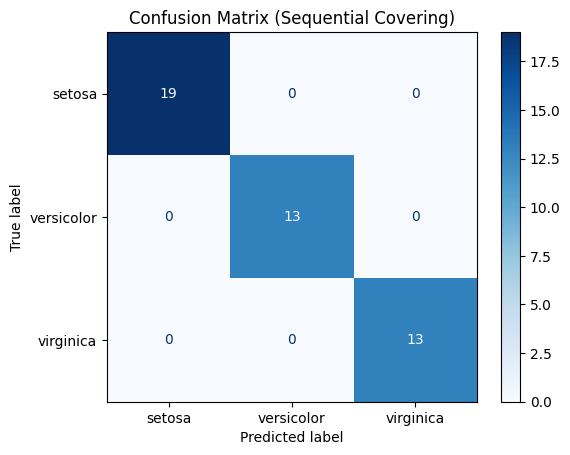

In [9]:
# TODO: Đánh giá mô hình: in Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# TODO: Vẽ confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
y_true = y_test
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["setosa", "versicolor", "virginica"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Sequential Covering)")
plt.show()

## Question 5
**Try different values of k (e.g., 1, 3, 5, 9) and observe how accuracy changes.**

In [12]:
# So sánh độ chính xác khi thay đổi k
for k in [1, 3, 5, 9]:
    # TODO: Khởi tạo mô hình với giá trị k khác nhau
    knn = KNeighborsClassifier(n_neighbors=k)
    # TODO: Huấn luyện mô hình
    knn.fit(X_train, y_train)
    # TODO: Dự đoán trên tập kiểm tra
    y_pred = knn.predict(X_test)
    # TODO: Tính độ chính xác
    acc = accuracy_score(y_test, y_pred)
    print(f"k = {k}, Accuracy = {acc:.2f}")

k = 1, Accuracy = 1.00
k = 3, Accuracy = 1.00
k = 5, Accuracy = 1.00
k = 9, Accuracy = 1.00


## Question 6
**Visualize the decision boundary of k-NN (k=5) using only two features of Iris dataset.**

_Hint: You can use `matplotlib` and `contourf()` to show colored regions._

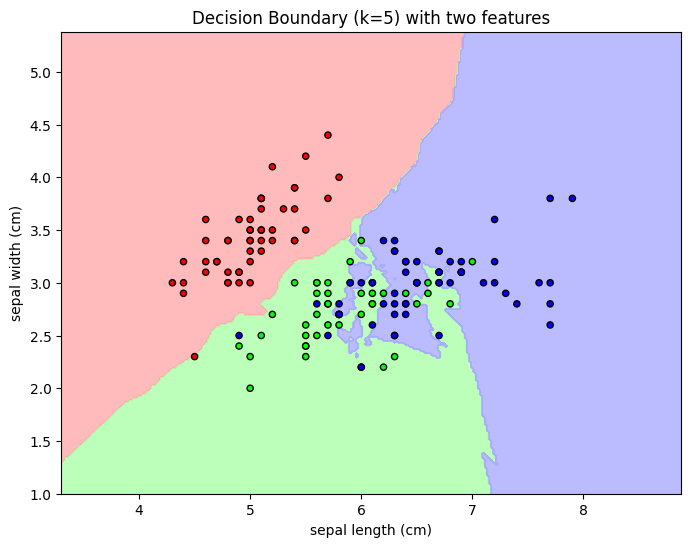

In [11]:
# Trực quan hóa biên phân loại kNN
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.neighbors import KNeighborsClassifier

# TODO: Chọn 2 thuộc tính đầu tiên để dễ vẽ
X_vis = data.data[:, :2]
y_vis = data.target

# TODO: Huấn luyện mô hình
knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_vis, y_vis)

# TODO: Tạo lưới điểm để dự đoán
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# TODO: Vẽ vùng quyết định
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

# Vẽ điểm dữ liệu
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap=cmap_bold, edgecolor='k', s=20)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('Decision Boundary (k=5) with two features')
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.show()

## Question 7
**Explain: What happens when k is too small or too large?**

_Answer in your own words below:_

- When k is too small, the model is highly sensitive to noise in the data. It will focus on the very nearest neighbors, which might be outliers, leading to a complex decision boundary and potentially overfitting.

- When k is too large, the model becomes overly smoothed and considers too many neighbors, including those from other classes. This can lead to underfitting and a less accurate model as it loses the ability to capture local patterns in the data.

*Gợi ý: k quá nhỏ -> mô hình nhạy cảm với nhiễu;
        k quá lớn -> mô hình bị làm mượt, giảm độ chính xác*